# 62 - Pooling

**Section:** Convolution and transformations | **Prereqs:** `Convolution and transformations/CodeChallenge_Choosing_Parameters.ipynb` | **Next:** `Convolution and transformations/Image_transformations.ipynb`

Pooling shrinks a feature map by summarising each small block with a single
number. It has **no parameters** - just a fixed reduction.

| | What it keeps | Typical use |
|---|---|---|
| **MaxPool2d** | the strongest response in each block | almost always - 'was this feature present anywhere here?' |
| **AvgPool2d** | the mean of each block | smoother; mostly as global average pooling at the end |

**Why pool**
- Fewer spatial positions means fewer parameters downstream and less compute.
- It buys a little *local* translation invariance: shift a feature by one pixel
  and the max over a 2x2 block is often unchanged.
- It widens the receptive field, so later layers see more of the image at once.

**`MaxPool2d(2,2)` halves height and width** - the standard building block.
Modern architectures increasingly use `stride=2` convolutions instead, which
downsample *and* learn while doing it, but pooling remains everywhere in the CNNs
you will read.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

!pip install torchvision
import torchvision
import torchvision.transforms as transforms

In [2]:
# A conv layer and a random image, to produce feature maps worth pooling.

img_size = (3,64,64)

input_chan = 3
ouput_chan = 10

stride = 2
padding = 0
kernal = 9

img = torch.rand(1,img_size[0],img_size[1],img_size[2])

c = nn.Conv2d(in_channels=input_chan, out_channels= ouput_chan , stride=stride, padding=padding, kernel_size=kernal)

In [4]:
# MaxPool2d(2,2) and AvgPool2d(2,2): kernel 2, stride 2, so blocks do not
# overlap and the output is exactly half the size in each dimension.
# (1,10,28,28) -> (1,10,14,14). Channels are untouched - pooling is purely
# spatial.
output = c(img)

max_pool = nn.MaxPool2d(2,2)
mean_pool = nn.AvgPool2d(2,2)

mean_o = mean_pool(output)
max_o = max_pool(output)



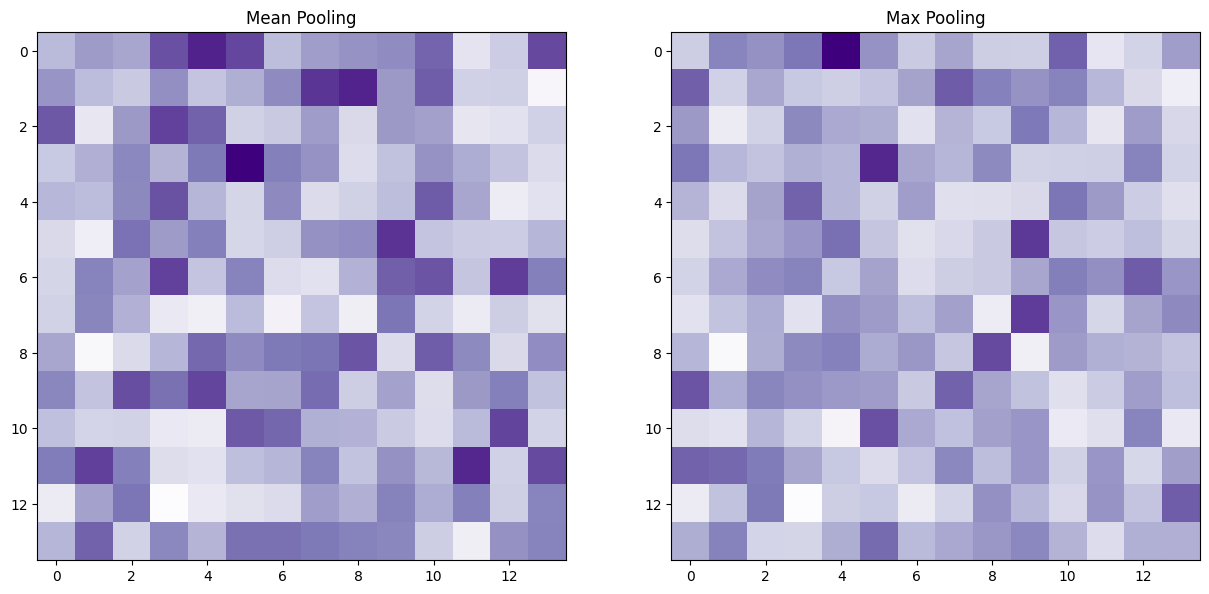

In [29]:
# Mean vs max pooling on the same feature map. Max is sharper and keeps peak
# responses; mean is smoother and dilutes an isolated strong activation.
# Max wins in practice because a feature detector's peak IS the signal - the
# question is 'is this pattern present', not 'what is its average strength'.
fig, ax  = plt.subplots(1,2, figsize=(15,7))

ax[0].imshow(mean_o[0, 0, :, :].detach().numpy(), cmap='Purples')
ax[0].set_title("Mean Pooling")

ax[1].imshow(max_o[0, 0, :, :].detach().numpy(), cmap='Purples')
ax[1].set_title("Max Pooling");

In [34]:
# The pooled tensor, squeezed for readability.
mean_o.squeeze()

tensor([[[ 0.0410,  0.0885,  0.0721,  ..., -0.0424,  0.0093,  0.2063],
         [ 0.1002,  0.0376,  0.0151,  ...,  0.0032,  0.0052, -0.0997],
         [ 0.1884, -0.0494,  0.0915,  ..., -0.0445, -0.0359,  0.0025],
         ...,
         [ 0.1436,  0.2173,  0.1368,  ...,  0.2486,  0.0032,  0.2044],
         [-0.0611,  0.0811,  0.1517,  ...,  0.1384,  0.0055,  0.1288],
         [ 0.0472,  0.1755, -0.0009,  ..., -0.0736,  0.1076,  0.1319]],

        [[-0.1947, -0.1125, -0.3017,  ..., -0.0889, -0.2801, -0.1632],
         [-0.2640, -0.2132, -0.1490,  ..., -0.2066, -0.2651, -0.2173],
         [-0.2732, -0.3352, -0.2934,  ..., -0.1570, -0.2849, -0.3064],
         ...,
         [-0.2151, -0.2409, -0.3259,  ..., -0.1448, -0.1470, -0.2648],
         [-0.2289, -0.0863, -0.2614,  ..., -0.3377, -0.2614, -0.2216],
         [-0.2700, -0.2544, -0.1211,  ..., -0.2037, -0.1943, -0.2910]],

        [[ 0.0665,  0.0523,  0.0034,  ..., -0.0993, -0.1399, -0.1717],
         [-0.0765, -0.1630, -0.1531,  ..., -0